# 01 — Setup and Data Inspection

Sanity-check the UD treebanks and both parsers on a handful of sentences.

In [1]:
# === Kaggle / Colab setup (skip if running locally) ===
import os, subprocess, sys
from pathlib import Path

IS_KAGGLE = Path("/kaggle/working").exists()
IS_COLAB  = "google.colab" in sys.modules

if IS_KAGGLE or IS_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "-r", "../requirements.txt"], check=True)
    # Kaggle ships pandas built against numpy 2.x, but spacy 3.7.5 pins numpy<2.
    # Force-reinstall pandas+numpy together so binary ABI matches.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "--force-reinstall", "--no-deps",
                    "numpy<2", "pandas>=2.0,<2.3"], check=True)
    subprocess.run([sys.executable, "-m", "spacy", "download",
                    "en_core_web_trf"], check=True)
    subprocess.run([sys.executable, "-m", "spacy", "download",
                    "ru_core_news_lg"], check=True)
    subprocess.run([sys.executable, "../scripts/download_data.py"],
                   check=True)
    print("Setup done.")
else:
    print("Local env detected — skipping cloud setup.")


Local env detected — skipping cloud setup.


In [2]:
import sys
sys.path.insert(0, "..")

from pathlib import Path
from src.data import load_sentences

EN = load_sentences(Path("../data/en_ewt_test.conllu"))
RU = load_sentences(Path("../data/ru_syntagrus_test.conllu"))

print(f"English-EWT test:       {len(EN)} sentences, {sum(len(s.tokens) for s in EN)} tokens")
print(f"Russian-SynTagRus test: {len(RU)} sentences, {sum(len(s.tokens) for s in RU)} tokens")

English-EWT test:       2077 sentences, 25094 tokens
Russian-SynTagRus test: 8800 sentences, 157718 tokens


In [3]:
import pandas as pd

df = pd.DataFrame(
    [{"lang": "en", "len": len(s.tokens)} for s in EN] +
    [{"lang": "ru", "len": len(s.tokens)} for s in RU]
)
df.groupby("lang")["len"].describe()

,count,mean,std,min,25%,50%,75%,max
lang,,,,,,,,
en,2077.0,12.081849,10.605604,1.0,4.0,9.0,17.0,81.0
ru,8800.0,17.922500,11.153483,2.0,10.0,16.0,23.0,123.0


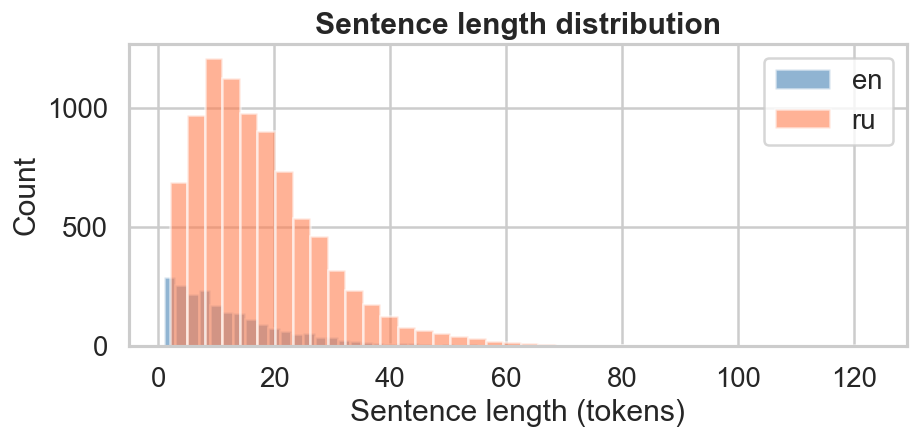

In [4]:
import matplotlib.pyplot as plt
from src.plotting import apply_poster_style
apply_poster_style()

fig, ax = plt.subplots(figsize=(8, 4))
for lang, sents, color in [("en", EN, "steelblue"), ("ru", RU, "coral")]:
    lengths = [len(s.tokens) for s in sents]
    ax.hist(lengths, bins=40, alpha=0.6, label=lang, color=color)
ax.set_xlabel("Sentence length (tokens)")
ax.set_ylabel("Count")
ax.set_title("Sentence length distribution")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
from src.parsers import SpacyParser, StanzaParser

sample_en = [EN[0].tokens]
spacy_en = SpacyParser("en_core_web_trf")
stanza_en = StanzaParser("en")

print("=== Sample sentence ===")
print("Tokens:", EN[0].tokens)
print()
print("GOLD   heads:", EN[0].heads)
print("GOLD   deprels:", EN[0].deprels)
print()
spacy_res = spacy_en.parse(sample_en)[0]
print("spaCy  heads:", spacy_res.heads)
print("spaCy  deprels:", spacy_res.deprels)
print()
stanza_res = stanza_en.parse(sample_en)[0]
print("Stanza heads:", stanza_res.heads)
print("Stanza deprels:", stanza_res.deprels)

=== Sample sentence ===
Tokens: ['What', 'if', 'Google', 'Morphed', 'Into', 'GoogleOS', '?']

GOLD   heads: [0, 4, 4, 1, 6, 4, 4]
GOLD   deprels: ['root', 'mark', 'nsubj', 'advcl', 'case', 'obl', 'punct']

spaCy  heads: [0, 4, 4, 1, 4, 5, 1]
spaCy  deprels: ['root', 'mark', 'nsubj', 'advcl', 'prep', 'pobj', 'punct']

Stanza heads: [0, 4, 4, 1, 6, 4, 1]
Stanza deprels: ['root', 'mark', 'nsubj', 'advcl', 'case', 'obl', 'punct']


/Users/aleksandrgavkovskij/programming/nlp_case_study/.venv/lib/python3.12/site-packages/thinc/shims/pytorch.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self._mixed_precision):


## What we learned (from this run)

- **Sizes confirmed:** EN-EWT test = 2,077 sentences / 25,094 tokens; RU-SynTagRus test = 8,800 sentences / 157,718 tokens.
- **Russian is longer on average:** median RU sentence = 16 tokens vs EN = 9; 75th percentile = 23 vs 17; RU max = 123 tokens, EN max = 81. Long-sentence bucket (40+) will therefore contain ~7× more RU sentences than EN in notebook 04.
- **Sanity check on sample sentence "What if Google Morphed Into GoogleOS?":** Stanza matched gold heads on 6/7 tokens and gold deprels on 6/7 (only root→punct attachment differs). spaCy matched gold heads on only 4/7 and produced CLEAR-style labels (`prep`, `pobj`) instead of UD (`case`, `obl`) — the label-scheme caveat is visible at the level of a single sentence.
- **Format confirmed:** both parsers return 1-indexed heads with 0 = ROOT, same convention as gold CoNLL-U.
